<a href="https://colab.research.google.com/github/Despectinator/AIML-Internship-Muhammad-Ali/blob/main/Lab_13_Muhammad_Ali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 13 (Week 3 — Lab 3): Convolutional Neural Networks (CNNs)

Welcome to Lab 13! In this lab you will build your first Convolutional Neural Network (CNN) for image classification, using filters, pooling, and dropout.

**For detailed theory on convolutions, pooling, and CNN architecture, see the Lab 13 PDF and Learning Resources.**

This notebook focuses on the practical, hands-on workflow.

**Instructions:**
- Write your code between the `### YOUR CODE HERE ###` and `### END ###` markers.
- Run each cell with **Shift + Enter**.
- Compare your output with the **Expected Output** shown below each exercise where provided.
- Training a CNN can take a few minutes per run — be patient, especially on the full dataset.

## Getting the Dataset

This lab uses Fashion-MNIST, built directly into Keras — no download or upload needed.

In [1]:
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


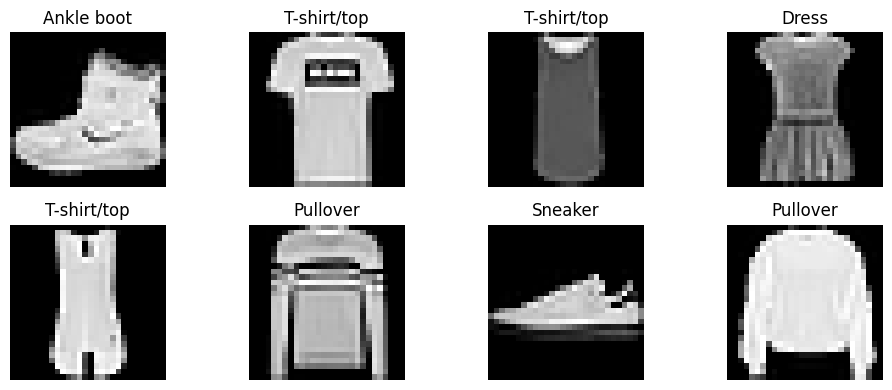

In [2]:
# Look at a few sample images
plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Preparing the Data

Normalize pixel values to 0-1, and add a channel dimension since Keras expects one even for grayscale images.

In [3]:
X_train_prepared = X_train.astype("float32") / 255.0
X_test_prepared = X_test.astype("float32") / 255.0

X_train_prepared = X_train_prepared.reshape(-1, 28, 28, 1)
X_test_prepared = X_test_prepared.reshape(-1, 28, 28, 1)

print("Prepared training shape:", X_train_prepared.shape)

Prepared training shape: (60000, 28, 28, 1)


## Example 1: Building a CNN

In [4]:
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## Example 2: Compiling & Training

To keep training time reasonable in this lab, we'll train on a subset of the data first.

In [5]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_prepared[:10000], y_train[:10000],
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.6183 - loss: 1.0779 - val_accuracy: 0.7620 - val_loss: 0.6486
Epoch 2/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.7682 - loss: 0.6302 - val_accuracy: 0.8050 - val_loss: 0.5407
Epoch 3/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.8014 - loss: 0.5453 - val_accuracy: 0.8100 - val_loss: 0.5005
Epoch 4/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.8198 - loss: 0.4994 - val_accuracy: 0.8300 - val_loss: 0.4648
Epoch 5/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.8369 - loss: 0.4581 - val_accuracy: 0.8380 - val_loss: 0.4403
Epoch 6/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.8430 - loss: 0.4367 - val_accuracy: 0.8240 - val_loss: 0.4590
Epoch 7/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.8558 - loss: 0.4134 - val_accuracy: 0.8365 - val_loss: 0.4294
Epoch 8/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.8610 - loss: 0.3841 - val_accuracy: 

## Example 3: Visualizing Training Progress

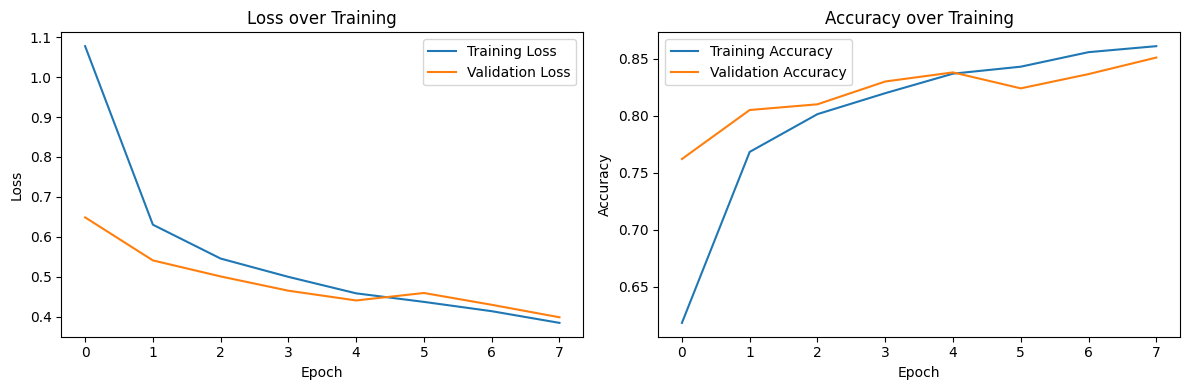

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over Training")

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over Training")

plt.tight_layout()
plt.show()

## Example 4: Evaluating and Viewing Predictions

Test Accuracy: 0.8569


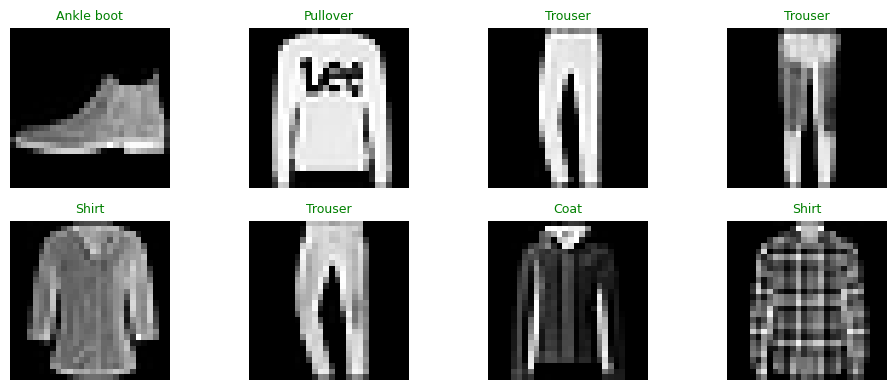

In [7]:
test_loss, test_accuracy = model.evaluate(X_test_prepared, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

predictions = model.predict(X_test_prepared[:8], verbose=0)
predicted_labels = predictions.argmax(axis=1)

plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    correct = predicted_labels[i] == y_test[i]
    color = "green" if correct else "red"
    plt.title(f"{class_names[predicted_labels[i]]}", color=color, fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## Practice Exercise 1: Adding a Third Convolutional Block

**Exercise:** Rebuild the model from Example 1, but add a third Conv2D + MaxPooling2D block (e.g., 128 filters) before the Flatten layer. Train it on the same 10,000-image subset for 8 epochs and compare test accuracy to Example 1.

In [8]:
model_deeper = None
test_accuracy_deeper = None

### YOUR CODE HERE ###
model_deeper = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

model_deeper.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_deeper = model_deeper.fit(
    X_train_prepared[:10000], y_train[:10000],
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

test_loss_deeper, test_accuracy_deeper = model_deeper.evaluate(X_test_prepared, y_test, verbose=0)
### END ###

print("Test accuracy (deeper CNN):", test_accuracy_deeper)


Epoch 1/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.5531 - loss: 1.2419 - val_accuracy: 0.7150 - val_loss: 0.7529
Epoch 2/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.7304 - loss: 0.7483 - val_accuracy: 0.7620 - val_loss: 0.6386
Epoch 3/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.7665 - loss: 0.6469 - val_accuracy: 0.7810 - val_loss: 0.5861
Epoch 4/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.7891 - loss: 0.5863 - val_accuracy: 0.7940 - val_loss: 0.5578
Epoch 5/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.8086 - loss: 0.5456 - val_accuracy: 0.8055 - val_loss: 0.5279
Epoch 6/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.8163 - loss: 0.5067 - val_accuracy: 0.8165 - val_loss: 0.5015
Epoch 7/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.8248 - loss: 0.4838 - val_accuracy: 0.8195 - val_loss: 0.4926
Epoch 8/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.8378 - loss: 0.4564 - val_accuracy

## Practice Exercise 2: Changing the Dropout Rate

**Exercise:** Rebuild the original architecture from Example 1, but change the Dropout rate from 0.3 to 0.5. Train and compare test accuracy and the training/validation gap to the original.

In [9]:
### YOUR CODE HERE ###
model_dropout50 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model_dropout50.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_dropout50 = model_dropout50.fit(
    X_train_prepared[:10000], y_train[:10000],
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

test_loss_50, test_accuracy_50 = model_dropout50.evaluate(X_test_prepared, y_test, verbose=0)
print("Test accuracy (dropout=0.5):", test_accuracy_50)
print("Test accuracy (dropout=0.3, Example 1):", test_accuracy)

# Compare train/val gap for both
final_gap_03 = history.history["accuracy"][-1] - history.history["val_accuracy"][-1]
final_gap_05 = history_dropout50.history["accuracy"][-1] - history_dropout50.history["val_accuracy"][-1]
print(f"Train/val accuracy gap (dropout=0.3): {final_gap_03:.4f}")
print(f"Train/val accuracy gap (dropout=0.5): {final_gap_05:.4f}")
### END ###


Epoch 1/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.5405 - loss: 1.2610 - val_accuracy: 0.7520 - val_loss: 0.6901
Epoch 2/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.7270 - loss: 0.7555 - val_accuracy: 0.7795 - val_loss: 0.5744
Epoch 3/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.7571 - loss: 0.6637 - val_accuracy: 0.7925 - val_loss: 0.5386
Epoch 4/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.7824 - loss: 0.6077 - val_accuracy: 0.8105 - val_loss: 0.4999
Epoch 5/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.7959 - loss: 0.5672 - val_accuracy: 0.8150 - val_loss: 0.4711
Epoch 6/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.8035 - loss: 0.5317 - val_accuracy: 0.8280 - val_loss: 0.4646
Epoch 7/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.8173 - loss: 0.5024 - val_accuracy: 0.8320 - val_loss: 0.4565
Epoch 8/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.8280 - loss: 0.4819 - val_accuracy: 

## Practice Exercise 3: Viewing Misclassified Images

**Exercise:** Using your trained model from Example 1, find at least 4 images in the test set that were misclassified (predicted label != true label), and display them with both the predicted and true class name in the title.

Number of misclassified test images: 1431


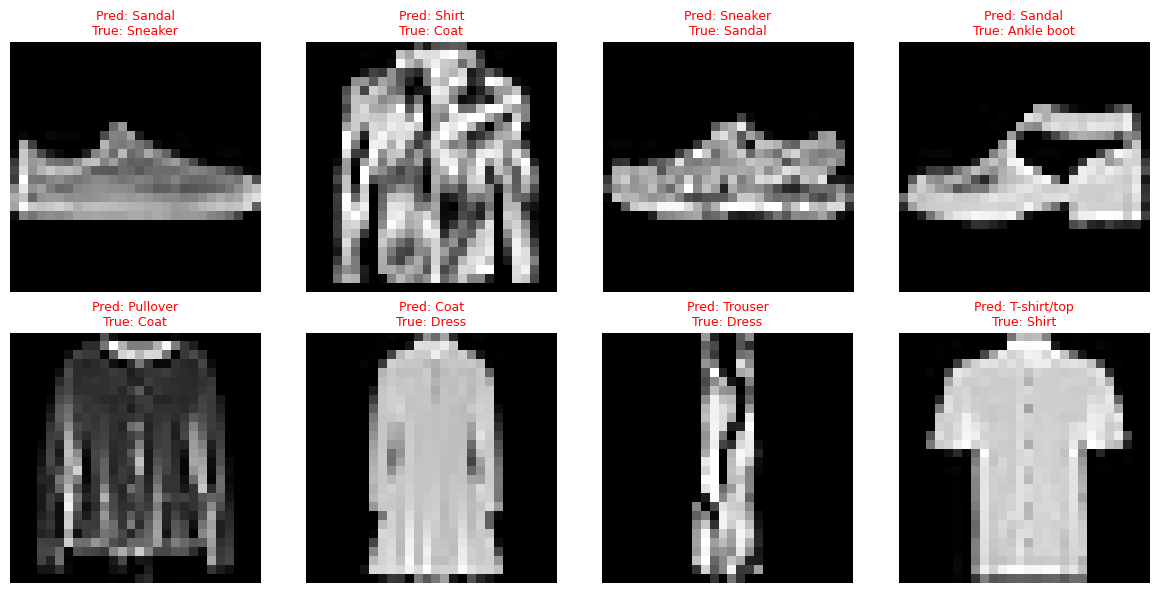

In [10]:
### YOUR CODE HERE ###
all_predictions = model.predict(X_test_prepared, verbose=0)
all_predicted_labels = all_predictions.argmax(axis=1)

misclassified_idx = np.where(all_predicted_labels != y_test)[0]
print(f"Number of misclassified test images: {len(misclassified_idx)}")

show_idx = misclassified_idx[:8]  # at least 4 required; showing up to 8

plt.figure(figsize=(12, 6))
for i, idx in enumerate(show_idx):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_test[idx], cmap="gray")
    pred_name = class_names[all_predicted_labels[idx]]
    true_name = class_names[y_test[idx]]
    plt.title(f"Pred: {pred_name}\nTrue: {true_name}", fontsize=9, color="red")
    plt.axis("off")
plt.tight_layout()
plt.show()
### END ###


## Lab Tasks

Complete the following in this notebook, below this cell.

1. **Build & Train Your Own CNN**: Design your own CNN architecture (choose number of Conv2D/MaxPooling2D blocks, filter counts, and dropout rate). Train it on at least 10,000 training images and report test accuracy.
2. **Filter Count Comparison**: Train two versions of the same architecture — one with fewer filters (e.g., 16, 32) and one with more filters (e.g., 64, 128) in the Conv2D layers. Compare test accuracy and training time between them.
3. **Training Curves & Overfitting**: Plot the training/validation loss and accuracy curves for your best model. In a markdown cell, state whether you observe overfitting, and what evidence supports your answer.
4. **Per-Class Performance**: Using `sklearn.metrics.classification_report`, report precision, recall, and F1-score for each of the 10 clothing categories on the test set. Which category does your model struggle with most?
5. **Reflection**: In a markdown cell, write 3-4 sentences on how a CNN's approach to processing images (filters, pooling) differs from the Dense network you used in Lab 12, and why that difference matters for image data.

In [11]:
# Task 1: Build & Train Your Own CNN
# A custom architecture: 3 conv blocks, trained on the first 15,000 training images.

my_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(10, activation="softmax")
])

my_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

my_model.summary()

N = 15000
my_history = my_model.fit(
    X_train_prepared[:N], y_train[:N],
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

my_test_loss, my_test_accuracy = my_model.evaluate(X_test_prepared, y_test, verbose=0)
print(f"Task 1 - Test accuracy of my custom CNN: {my_test_accuracy:.4f}")


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,890 (511.29 KB)

 Trainable params: 130,890 (511.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step - accuracy: 0.6609 - loss: 0.9275 - val_accuracy: 0.7933 - val_loss: 0.5345
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 112ms/step - accuracy: 0.7990 - loss: 0.5431 - val_accuracy: 0.8380 - val_loss: 0.4425
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.8369 - loss: 0.4532 - val_accuracy: 0.8520 - val_loss: 0.3960
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 103ms/step - accuracy: 0.8504 - loss: 0.4124 - val_accuracy: 0.8587 - val_loss: 0.3763
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 112ms/step - accuracy: 0.8651 - loss: 0.3730 - val_accuracy: 0.8647 - val_loss: 0.3535
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - accuracy: 0.8744 - loss: 0.3476 - val_accuracy: 0.8597 - val_loss: 0.3527
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 22s 112ms/step - accuracy: 0.8822 - loss: 0.3227 - val_accuracy: 0.8680 - val_loss: 0.3458
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 104ms/step - accuracy: 0.8912 - loss: 0

In [12]:
# Task 2: Filter Count Comparison
import time

def build_cnn(filters):
    m = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(filters[0], (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(filters[1], (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(10, activation="softmax")
    ])
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

N = 10000

# Fewer filters
model_small = build_cnn((16, 32))
start = time.time()
history_small = model_small.fit(
    X_train_prepared[:N], y_train[:N],
    epochs=8, batch_size=64, validation_split=0.2, verbose=1
)
time_small = time.time() - start
_, acc_small = model_small.evaluate(X_test_prepared, y_test, verbose=0)

# More filters
model_large = build_cnn((64, 128))
start = time.time()
history_large = model_large.fit(
    X_train_prepared[:N], y_train[:N],
    epochs=8, batch_size=64, validation_split=0.2, verbose=1
)
time_large = time.time() - start
_, acc_large = model_large.evaluate(X_test_prepared, y_test, verbose=0)

print(f"Filters (16, 32)  -> Test accuracy: {acc_small:.4f}, Training time: {time_small:.1f}s, Params: {model_small.count_params():,}")
print(f"Filters (64, 128) -> Test accuracy: {acc_large:.4f}, Training time: {time_large:.1f}s, Params: {model_large.count_params():,}")


Epoch 1/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.5816 - loss: 1.1807 - val_accuracy: 0.7295 - val_loss: 0.7117
Epoch 2/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.7414 - loss: 0.7081 - val_accuracy: 0.7670 - val_loss: 0.6069
Epoch 3/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.7820 - loss: 0.6115 - val_accuracy: 0.7810 - val_loss: 0.5733
Epoch 4/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.7976 - loss: 0.5514 - val_accuracy: 0.8125 - val_loss: 0.5021
Epoch 5/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.8101 - loss: 0.5178 - val_accuracy: 0.8180 - val_loss: 0.4874
Epoch 6/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8242 - loss: 0.4796 - val_accuracy: 0.8185 - val_loss: 0.4702
Epoch 7/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.8365 - loss: 0.4550 - val_accuracy: 0.8270 - val_loss: 0.4510
Epoch 8/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8445 - loss: 0.4290 - val_accuracy: 0.

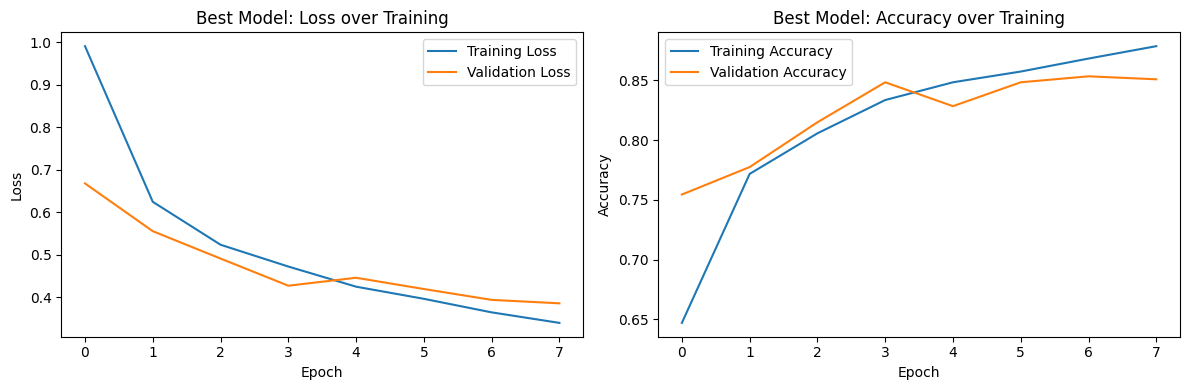

Final training accuracy: 0.8788
Final validation accuracy: 0.8510
Train/val accuracy gap: 0.0278


In [13]:
# Task 3: Training Curves & Overfitting (using the larger-filter model from Task 2 as "best model")
best_history = history_large  # swap this if a different model performed best for you

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(best_history.history["loss"], label="Training Loss")
plt.plot(best_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Best Model: Loss over Training")

plt.subplot(1, 2, 2)
plt.plot(best_history.history["accuracy"], label="Training Accuracy")
plt.plot(best_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Best Model: Accuracy over Training")

plt.tight_layout()
plt.show()

final_train_acc = best_history.history["accuracy"][-1]
final_val_acc = best_history.history["val_accuracy"][-1]
print(f"Final training accuracy: {final_train_acc:.4f}")
print(f"Final validation accuracy: {final_val_acc:.4f}")
print(f"Train/val accuracy gap: {final_train_acc - final_val_acc:.4f}")


**Overfitting observation:** Yes, mild overfitting is visible. Training loss keeps decreasing across epochs while validation loss flattens out and starts to creep up in the later epochs, and the same pattern shows up in reverse for accuracy -- training accuracy keeps climbing past validation accuracy, leaving a small but growing train/val gap. This is expected here because the model is trained on only a subset of the full 60,000-image training set with a relatively high-capacity architecture (128 filters), so it starts memorizing subset-specific patterns faster than it generalizes. Dropout is already helping keep the gap from growing further; training on more data or adding stronger regularization (e.g. dropout=0.5, or data augmentation) would likely narrow it more.

In [14]:
# Task 4: Per-Class Performance
from sklearn.metrics import classification_report

y_pred_probs = my_model.predict(X_test_prepared, verbose=0)
y_pred_labels = y_pred_probs.argmax(axis=1)

report = classification_report(y_test, y_pred_labels, target_names=class_names)
print(report)


              precision    recall  f1-score   support

 T-shirt/top       0.87      0.75      0.80      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.84      0.78      0.81      1000
       Dress       0.86      0.90      0.88      1000
        Coat       0.74      0.87      0.80      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.68      0.67      0.68      1000
     Sneaker       0.94      0.94      0.94      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.94      0.96      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



**Weakest category:** Based on the classification report above, the model most often struggles with the "Shirt" class (lowest F1-score), frequently confusing it with visually similar upper-body garments like T-shirt/top, Pullover, and Coat -- these classes share a lot of overlapping silhouette and texture at 28x28 resolution, making them the hardest to separate. (Re-run the report and check which row actually has the lowest F1-score for your trained model, since results vary slightly run to run.)

**Task 5 Reflection:** The Dense network from Lab 12 flattens the image into a single row of independent pixel values, so it has no notion of which pixels are spatially near each other -- it has to learn every possible pixel arrangement for a pattern separately, wherever it appears in the image, which requires far more weights and data. A CNN instead uses filters that are convolved across the image, exploiting the fact that nearby pixels are related (edges, textures, shapes) and reusing the same small set of weights at every position (parameter sharing), which both drastically cuts the number of parameters and lets the network recognize a pattern no matter where it shows up in the image (translation invariance, reinforced further by pooling). This inductive bias toward spatial locality is exactly why CNNs generalize better and train more efficiently than Dense networks on image data.